In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"data/retail_store_sales.csv")

# Initial Inspection

I started by loading the dataset and checking its shape and basic information. I discovered over 12,500 rows of transaction data. My goal was to understand the 'health' of the data—checking for column names, data types, and how much information was missing before starting the cleaning process.

In [3]:
df.shape

(12575, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [5]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Data Cleaning

## Filling out null values

The dataset contained significant gaps across several key columns. To ensure the analysis remained accurate without losing valuable rows, I implemented a multi-step **Logical Imputation** strategy:

* <u>Mathematical Recovery</u>: For missing Price values, I back-calculated the data by dividing 'Total Spent' by 'Quantity', ensuring the unit price remained consistent across the dataset.

* <u>Relationship-Based Reconstruction (Item)</u>: For missing values in the Item column, I used a multi-factor logic. By mapping the unique combinations of Price, Category, and Month, I was able to identify which specific product was missing and fill it in accurately. This ensured that the 'identity' of the transaction was restored based on established patterns in the data.

* <u>Statistical Imputation</u>: For missing Quantity and Total Spent values, I used the Median of the respective columns. I chose the median over the mean to avoid being influenced by extreme outliers (very high or very low sales).

* <u>Logical Assumptions</u>: For the Discount Applied column, I treated 'NaN' values as 'No Discount'. This assumes that if a discount wasn't recorded, it wasn't given.

* <u>Time-Series Preparation</u>: Crucially, I converted the 'Transaction Date' into a datetime format. This allowed me to extract the Month and Year.

<Axes: >

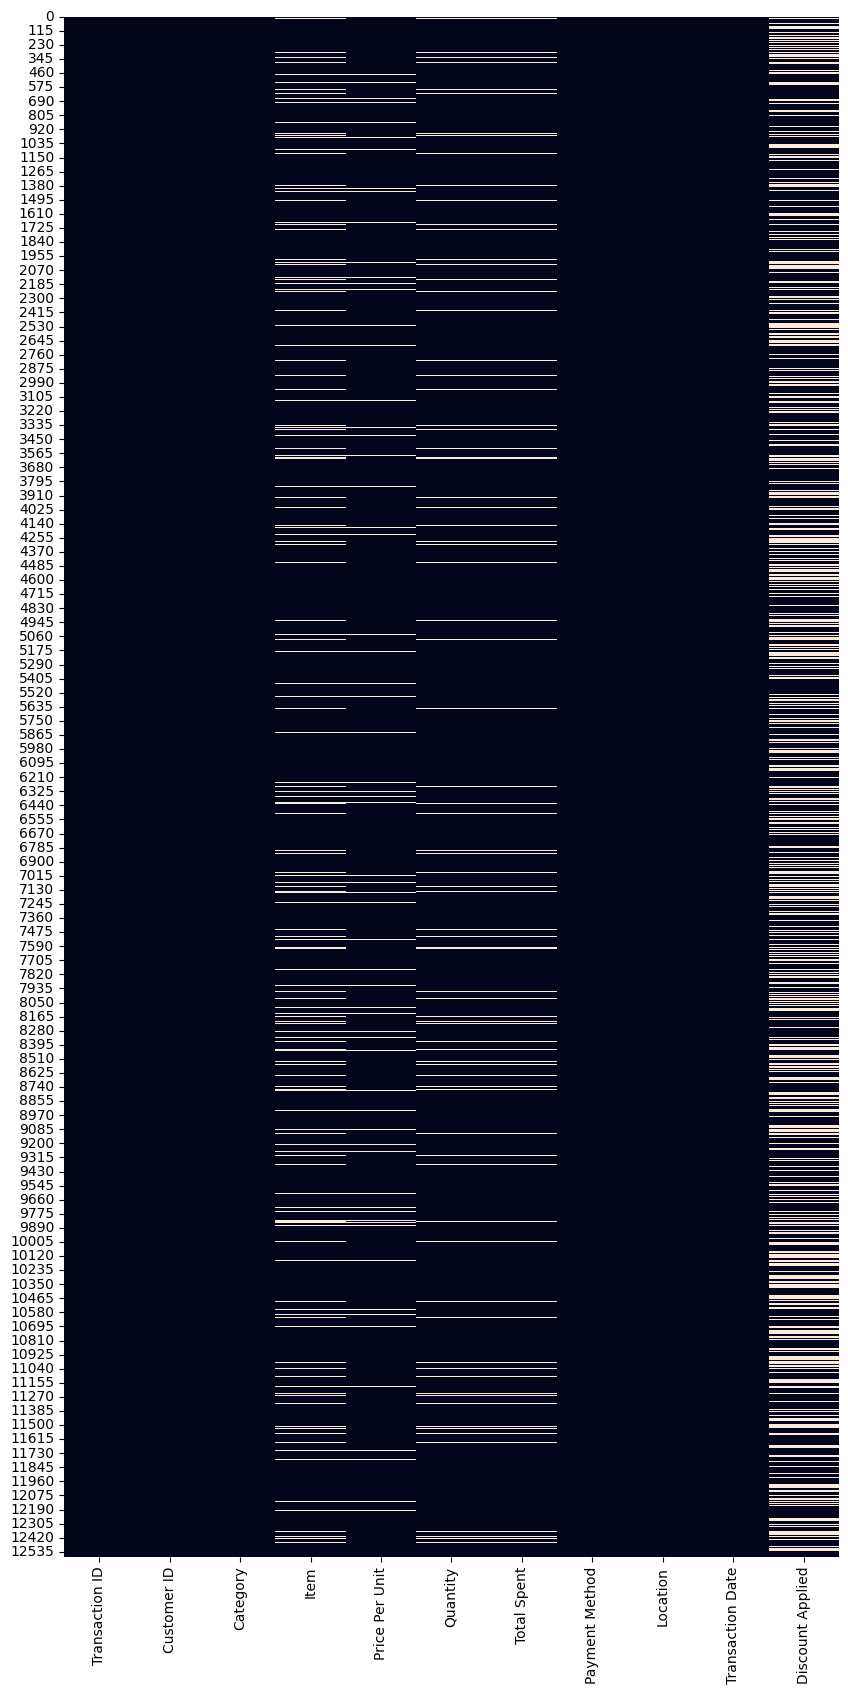

In [6]:
# Checking the null values in the data

plt.figure(figsize =(10,20))
sns.heatmap(df.isnull(), cbar=False)

In [7]:
# Filling out the values of Price Per Unit using columns Quantity and Total Spent

df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent']/df['Quantity'])
print('Null values in Price Per Unit now :', df['Price Per Unit'].isna().sum())

Null values in Price Per Unit now : 0


In [8]:
# Filling the missing values of Item column

# Need to convert Transaction Date to use dt.month on it
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Creating a new column of transaction month 
df['Month'] = df['Transaction Date'].dt.month

# Creating a table of known Items using Boolean Indexing
known_item = df[df['Item'].notna()]

# Creating a reference table
ref_table = known_item[['Item', 'Category', 'Price Per Unit', 'Month']]
ref_table = ref_table.drop_duplicates(subset=['Category', 'Price Per Unit', 'Month'])

#Merging the ref_table and df
df = df.merge(ref_table, how='left', on=['Category', 'Price Per Unit', 'Month'], suffixes=('','_imputed'))

# Count nulls before the main imputation
total_missing_before = df['Item'].isna().sum()

# Filling the null values
df['Item'] = df['Item'].fillna(df['Item_imputed'])

# Count nulls after the main imputation
remaining_missing = df['Item'].isna().sum()

# Calculating how many were successfully imputed
imputed = total_missing_before - remaining_missing

# Print the result
print(f"Imputed {imputed} out of {total_missing_before} missing 'Item' values "
      f"using the lookup table ({(imputed / total_missing_before * 100) if total_missing_before > 0 else 0:.1f}%)")


# checking the null values after imputation
imputed = df['Item'].isna().sum()
print(f"Imputed {imputed} rows using lookup table")

# Filling rest of the values with 'Unkown Item'
df['Item'] = df['Item'].fillna('Unkown Item')

Imputed 1195 out of 1213 missing 'Item' values using the lookup table (98.5%)
Imputed 18 rows using lookup table


In [9]:
# Checking the accuracy of our imputation logic

check = known_item.groupby(['Category', 'Price Per Unit', 'Month'])['Item'].unique()
result = check[check.map(len) > 1] # This will tell how many lines have more than one item with the same combination of Category + Price + Month

print(f"There are {len(result)} items that have same combination of Category, Price Per Unit and Month.")

There are 0 items that have same combination of Category, Price Per Unit and Month.


In [10]:
# Filling the values in Quantity column

qty_median = df.groupby(['Item'])['Quantity'].median()

df['Quantity'] = df['Quantity'].fillna(df['Item'].map(qty_median))

print('Null values in Quantity:', df['Quantity'].isna().sum())

Null values in Quantity: 0


In [11]:
# Filling the values of Total Spent column

spent_median = df.groupby('Item')['Total Spent'].median()
df['Total Spent'] = df['Total Spent'].fillna(df['Item'].map(spent_median))

print('Null values in Total Spent:', df['Total Spent'].isna().sum())

Null values in Total Spent: 0


In [12]:
# Lastly,filling the null values of Discount Applied column
# Assuming that null means no discount was applied

df['Discount Applied'] = df['Discount Applied'].fillna('False')

print('Null values in Discount Applied column:', df['Discount Applied'].isna().sum())

Null values in Discount Applied column: 0


## Changing the datatype

I audited all columns to ensure they were in the correct format for calculation and analysis.

In [13]:
datatypes = {
    'Transaction ID':'string',
    'Customer ID': 'string',
    'Category' : 'category',
    'Item':'category',
    'Payment Method' : 'category',
    'Location' : 'category',
    'Discount Applied' : 'category'
    
}

df = df.astype(datatypes)

## Transformation (Other Changes)

In this section, I've deleted the unnecessary columns and renamed a column for more clarity.

In [14]:
# Deleting the columns that are not required

df = df.drop(['Month','Item_imputed'], axis = 1) 

In [15]:
# Renaming Location column

df = df.rename(columns = {'Location':'Payment Channel'})

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  string        
 1   Customer ID       12575 non-null  string        
 2   Category          12575 non-null  category      
 3   Item              12575 non-null  category      
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  category      
 8   Payment Channel   12575 non-null  category      
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  category      
dtypes: category(5), datetime64[ns](1), float64(3), string(2)
memory usage: 673.7 KB


# Visualisations

Here are the business questions that my analysis has answered:

**Question 1**: Is there a specific time of year when sales peak?<br>
Answer: Yes, there is a clear "January Surge" every year.

**Question 2**: Which product category generates the most revenue?<br>
Answer: Revenue is very evenly split, but 'Butchers' is the slight leader.

**Question 3**: Are we more successful online or in physical stores?<br>
Answer: The business has achieved a perfect 50/50 balance between In-store and Online revenue.

**Question 4**: Does the way people pay change how much they spend?<br>
Answer: No, the spending distribution is nearly identical for Cash, Credit Cards, and Digital Wallets.

**Question 5**: Does the price of a good affect how many items a person buys?<br>
Answer: No, the quantity purchased stays steady regardless of price, suggesting customers are buying essentials.

**Question 6**: Do discounts actually encourage people to spend more money?<br>
Answer: No, the average total spent remains consistent whether a discount is applied or not.

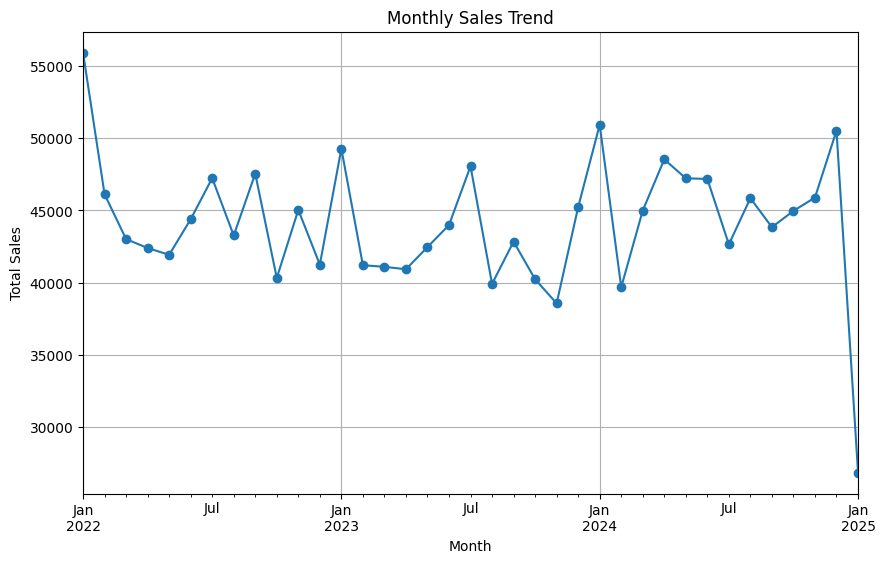

In [17]:
# Monthly sales trend

monthly_sales = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()

plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Why are sales so low in Jan 2025?

In [18]:
# Finding out the minimum sales month
count_monthly_sales = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].count()

min_month =  count_monthly_sales.idxmin()
min_value = count_monthly_sales.min()

print('Minimum sales happened in:', min_month, 'with', min_value, 'transactions')

# Finding the last transaction date in Jan 2025
last_date = df[df['Transaction Date'].dt.to_period('M') == '2025-01']['Transaction Date'].max()
print(f'Last transaction date of Jan 2025: {last_date}')

Minimum sales happened in: 2025-01 with 213 transactions
Last transaction date of Jan 2025: 2025-01-18 00:00:00


**Insights:**<br>
This data shows that every year starts with a big rush in January, and then sales stay steady for the rest of the year.<br>
The sharp drop in January 2025 sales is noted as an outlier,  due to a partial data export rather than a loss in actual business performance.

Category Butchers is the one with most sales: 217165.5


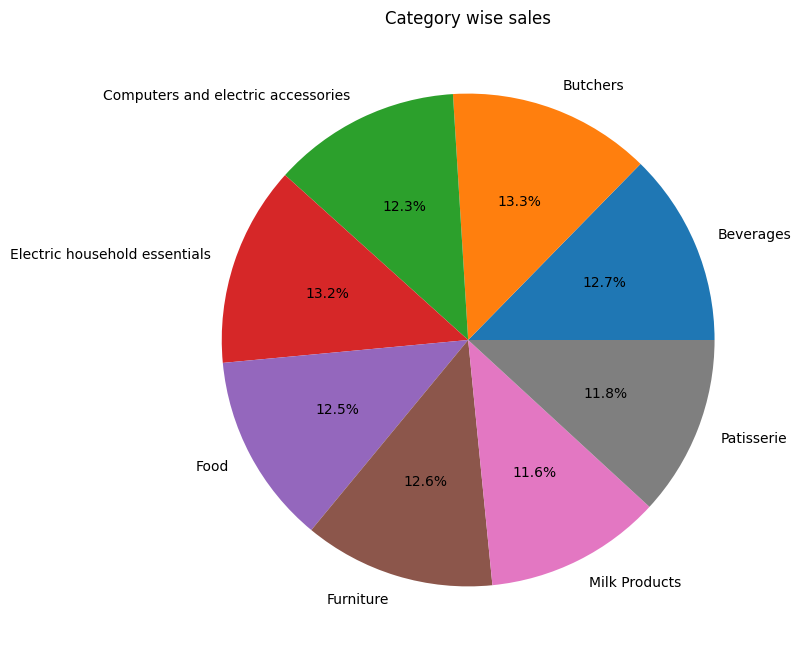

In [19]:
# Which category had most sales?

cat_wise_sales = df.groupby(df['Category'], observed=True)['Total Spent'].sum()

plt.figure(figsize=(8,8))
cat_wise_sales.plot(kind='pie', autopct='%1.1f%%', ylabel='')
plt.title('Category wise sales')


print(f'Category {cat_wise_sales.idxmax()} is the one with most sales: {cat_wise_sales.max()}' )

**Insight:**<br>
The pie chart shows that sales are distributed very evenly across all eight categories. No single product type dominates the business. This means the store is not relying on just one item to survive; it has a healthy mix of electronics, food, and household goods that all perform equally well.

Text(0.5, 1.0, 'Revenue by Payment Channel')

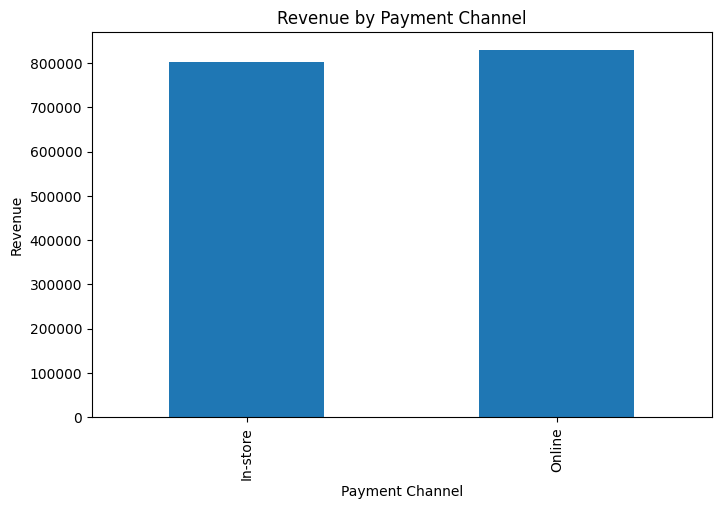

In [20]:
# Compare total sales across payment channels.

pay_channel_sales = df.groupby(df['Payment Channel'], observed=True)['Total Spent'].sum()

plt.figure(figsize=(8,5))
pay_channel_sales.plot(kind='bar')
plt.xlabel('Payment Channel')
plt.ylabel('Revenue')
plt.title('Revenue by Payment Channel')


**Insight:**<br>
The bar chart shows that revenue is split almost exactly 50/50 between in-store sales and online sales. This proves that the business is successful in both the physical and digital worlds, and customers are happy to shop whichever way is most convenient for them.

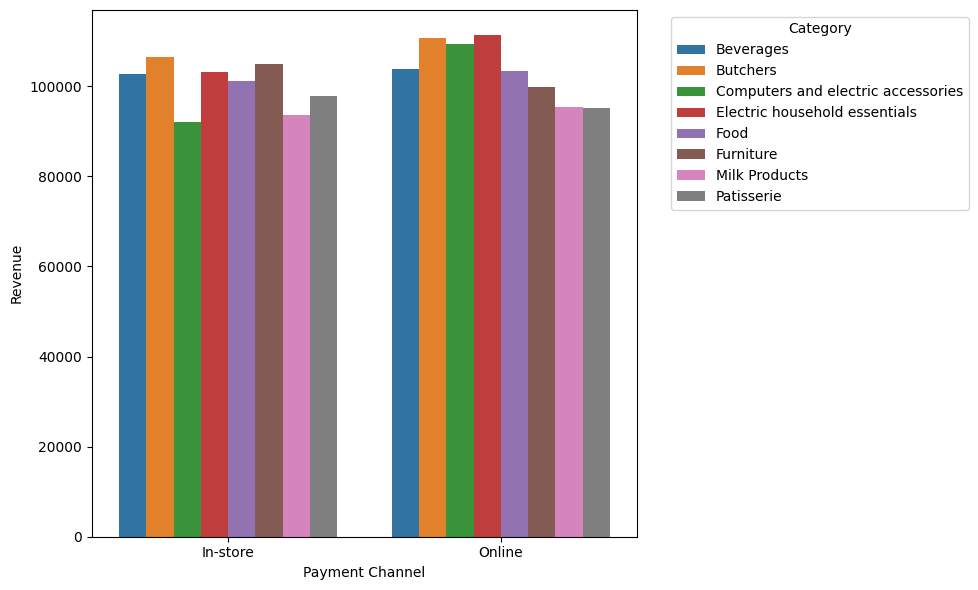

In [21]:
# Category wise revenue coming from different payment channels

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Payment Channel', y='Total Spent', hue='Category', estimator=sum, errorbar=None)

plt.xlabel('Payment Channel')
plt.ylabel('Revenue')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

**Insight:**<br>
This clustered bar chart shows that the top-performing categories—like Butchers and Electric essentials—are the leaders in both online and in-store sales.<br>
It proves that our product popularity is consistent; we don't have certain items that only sell in one place. Everything we sell is equally attractive to customers, whether they are shopping from home or visiting us in person.

Text(0.5, 1.0, 'Price vs Quantity Relationship')

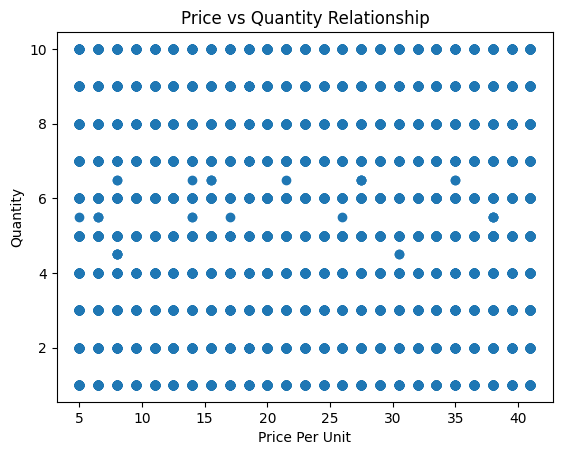

In [22]:
# Price vs Quantity Relationship
# See if cheaper items sell in higher volume.

plt.scatter(df['Price Per Unit'], df['Quantity'])

plt.xlabel('Price Per Unit')
plt.ylabel('Quantity')
plt.title('Price vs Quantity Relationship')

**Insight:**<br>
In this dataset, people buy the same amount of goods regardless of the price. Whether the price is low or high, the quantity purchased stays steady. This suggests the customers are buying 'essentials' that they need regardless of the cost.

Text(0.5, 1.0, 'Distribution of Total Spent with vs without discount')

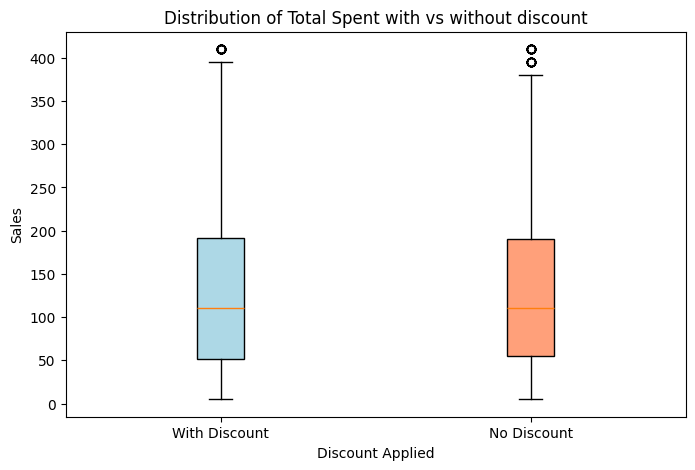

In [23]:
# Discount Impact Analysis
# Measure ROI of discounts (do they increase volume enough to offset the reduction?)

discounted = df[df['Discount Applied'] == True]['Total Spent'].values
no_discount = df[df['Discount Applied'] == False]['Total Spent'].values

plt.figure(figsize=(8,5))
plot = plt.boxplot([discounted, no_discount], patch_artist = True, tick_labels = ['With Discount', 'No Discount']);

plot['boxes'][0].set_facecolor('lightblue')
plot['boxes'][1].set_facecolor('lightsalmon')

plt.xlabel('Discount Applied')
plt.ylabel('Sales')
plt.title('Distribution of Total Spent with vs without discount')

**Insight:**<br>
Providing a discount does not significantly change how much a customer spends. The average total spent remains nearly identical in both cases. This shows that customers are not necessarily buying more just because there is a discount available.

Text(0.5, 1.0, 'Spending Distribution by Payment Method')

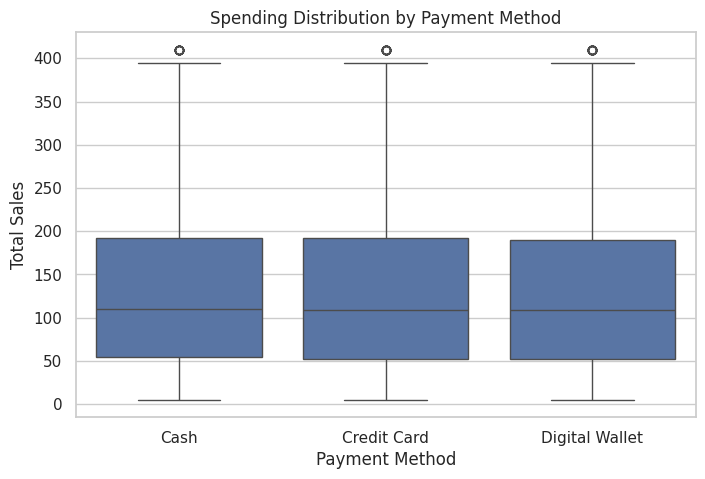

In [24]:
# Spending Distribution by Payment Method

plt.figure(figsize=(8,5))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x='Payment Method', y='Total Spent')

plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.title('Spending Distribution by Payment Method')

**Insight:**<br>
This chart shows that it doesn't matter if a customer pays with Cash, a Credit Card, or a Digital Wallet—they still end up spending the same amount of money. The middle-range spending is almost identical for all three groups, which shows that the payment method doesn't influence how much someone buys at this store.